## Linear Regression


### Import Dependencies

In [1]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import pickle

### Store data into variables in preparation for Model

In [2]:
# Create a data frame from the csv file
training_data = pd.read_csv('2.3.1.training_data.csv')

x_name = 'k/d'
y_name = 'win%'
x = np.array(training_data[x_name]).reshape(-1, 1)
y = np.array(training_data[y_name])

### Plot features on graphs for analysis


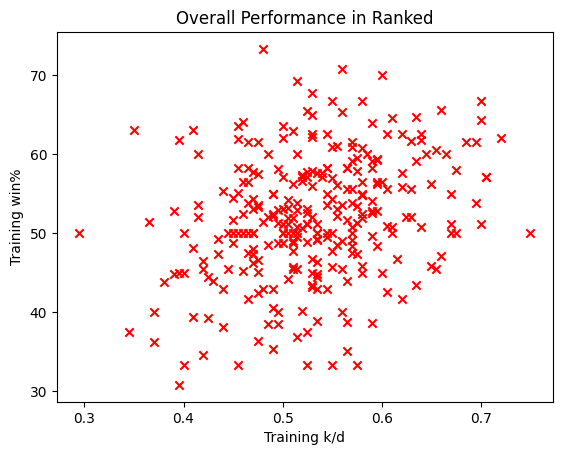

In [4]:
# Plot the data points
plt.scatter(x, y, marker="x", c="r")
# Set the title
plt.title("Overall Performance in Ranked")
# Set the y-axis label
plt.ylabel(f"Training {training_data[y_name].name}")
# Set the x-axis label
plt.xlabel(f"Training {training_data[x_name].name}")
plt.show()

### Instantiate Model

In [5]:
# Create the model
my_model = LinearRegression()
# Fit the model to the data
my_model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Visually represent Linear Regression through Matplotlib

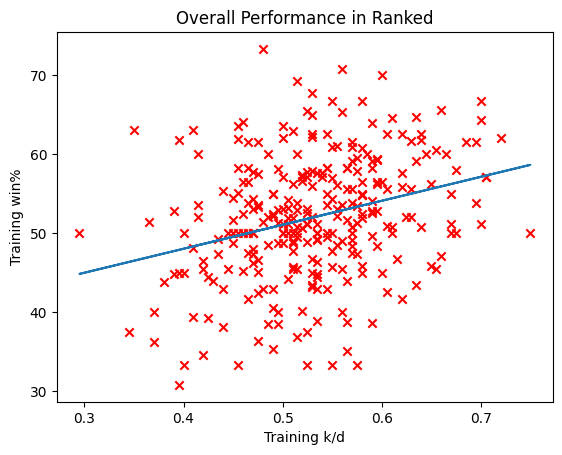

In [6]:
y_pred = my_model.predict(x)
plt.plot(x, y_pred)
plt.scatter(x, y, marker="x", c="r")
plt.title("Overall Performance in Ranked")
plt.ylabel(f"Training {training_data[y_name].name}")
plt.xlabel(f"Training {training_data[x_name].name}")
plt.show()

### Save model in preparation for evaluation and deployment

There are two model exports so that I can compare the data to hasten the process of finding the most efficient model. When saving models I'll simply comment the other line of code to prevent it from raising an error or interfering with the model's save file.

In [ ]:
# Save individual model to specific disk
filename = "linear_model1.sav"
pickle.dump(my_model, open("../2.4.Model_Testing_and_Evaluation/" + filename, "wb"))

filename = "linear_model2.sav"
pickle.dump(my_model, open("../2.4.Model_Testing_and_Evaluation/" + filename, "wb"))

## Multiple Feature Linear Regression

### Insert features and targets into variables for model

In [8]:
# Create a data frame from the csv file
training_data = pd.read_csv("2.3.1.training_data.csv")

x_name = ["k/d", "matchs_played", "headshot_%", "dmg/rnd"]
y_name = "win%"
x = np.array(training_data[x_name])
y = np.array(training_data[y_name])

### Plot features against Target 

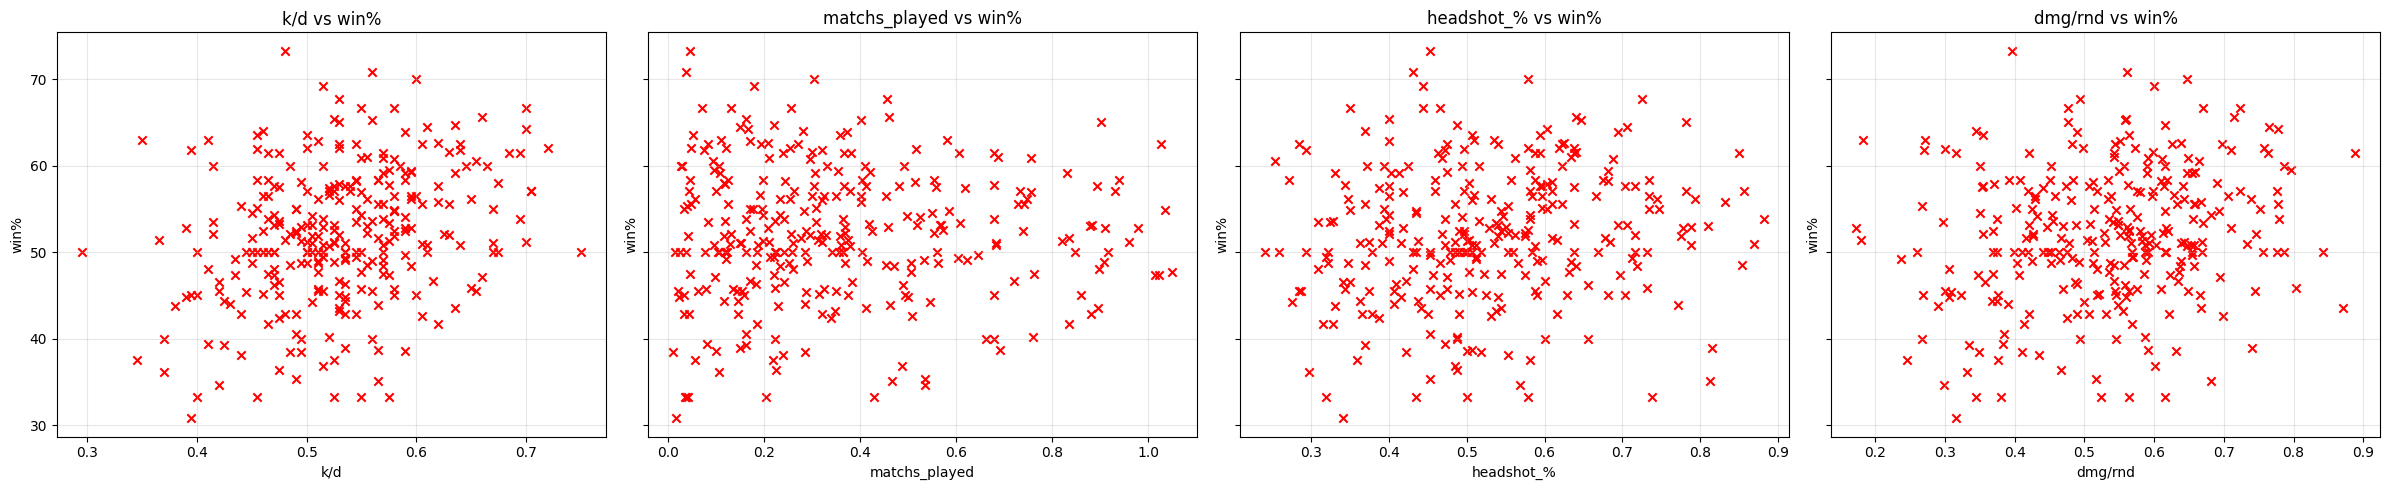

In [ ]:

# Plot each feature vs target individually
fig, axes = plt.subplots(1, len(x_name), figsize=(6 * len(x_name), 5), sharey=True)

if len(x_name) == 1:
    axes = [axes]

for i, feature in enumerate(x_name):
    axes[i].scatter(training_data[feature], training_data[y_name], marker="x", c="r")
    axes[i].set_title(f"{feature} vs {y_name}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(y_name)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Instantiate and fit model

In [10]:
# Instantiate model
my_model = LinearRegression()
# Fit the model to the data
my_model.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Plot predictions on graphs for quick model evaluation

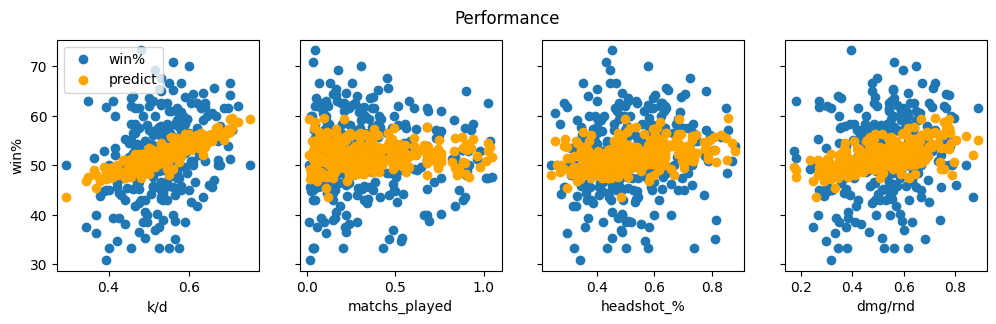

In [11]:
# scatter plot predictions and targets vs original features
y_pred = my_model.predict(x)
fig, ax = plt.subplots(1, len(x_name), figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x[:, i], y, label="win%")
    ax[i].set_xlabel(x_name[i])
    ax[i].scatter(x[:, i], y_pred, color="orange", label="predict")
ax[0].set_ylabel("win%")
ax[0].legend()
fig.suptitle("Performance")
plt.show()

### Pickle model in preparation for evaluation

In [12]:
# save the model to disk
filename = "multi_linear_model.sav"
pickle.dump(my_model, open("../2.4.Model_Testing_and_Evaluation/" + filename, "wb"))